In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)

In [2]:
DATA_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")

In [3]:
df = pd.read_csv(PROCESSED_DIR / "olist_orders_abt.csv")
df.head()

,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_year,order_month,order_day,order_day_of_week,order_hour,delivery_days,estimated_delivery_days,delivery_delay_days,is_late_delivery,review_score,is_low_review,review_comment_count,has_review_comment,total_payment_value,max_payment_installments,payment_types_count,dominant_payment_type,total_items,total_price,total_freight,unique_products,unique_sellers,main_product_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,delivered,2017,10,2,0,10,8.0,15,-8.0,0,4.0,0,1.0,1.0,38.71,1.0,2.0,voucher,1.0,29.99,8.72,1.0,1.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,delivered,2018,7,24,1,20,13.0,19,-6.0,0,4.0,0,1.0,1.0,141.46,1.0,1.0,boleto,1.0,118.70,22.76,1.0,1.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,delivered,2018,8,8,2,8,9.0,26,-18.0,0,5.0,0,0.0,0.0,179.12,3.0,1.0,credit_card,1.0,159.90,19.22,1.0,1.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,delivered,2017,11,18,5,19,13.0,26,-13.0,0,5.0,0,1.0,1.0,72.20,1.0,1.0,credit_card,1.0,45.00,27.20,1.0,1.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,delivered,2018,2,13,1,21,2.0,12,-10.0,0,5.0,0,0.0,0.0,28.62,1.0,1.0,credit_card,1.0,19.90,8.72,1.0,1.0,stationery


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (99441, 29)


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  99441 non-null  str    
 1   customer_id               99441 non-null  str    
 2   customer_unique_id        99441 non-null  str    
 3   customer_city             99441 non-null  str    
 4   customer_state            99441 non-null  str    
 5   order_status              99441 non-null  str    
 6   order_year                99441 non-null  int64  
 7   order_month               99441 non-null  int64  
 8   order_day                 99441 non-null  int64  
 9   order_day_of_week         99441 non-null  int64  
 10  order_hour                99441 non-null  int64  
 11  delivery_days             96476 non-null  float64
 12  estimated_delivery_days   99441 non-null  int64  
 13  delivery_delay_days       96476 non-null  float64
 14  is_late_delivery 

In [6]:
print("Columns in Dataset:\n")
print(df.columns.tolist())

Columns in Dataset:

['order_id', 'customer_id', 'customer_unique_id', 'customer_city', 'customer_state', 'order_status', 'order_year', 'order_month', 'order_day', 'order_day_of_week', 'order_hour', 'delivery_days', 'estimated_delivery_days', 'delivery_delay_days', 'is_late_delivery', 'review_score', 'is_low_review', 'review_comment_count', 'has_review_comment', 'total_payment_value', 'max_payment_installments', 'payment_types_count', 'dominant_payment_type', 'total_items', 'total_price', 'total_freight', 'unique_products', 'unique_sellers', 'main_product_category']


In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,99441,99441,e481f51cbdc54678b7cc49136f2d6af7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,99441,99441,9ef432eb6251297304e76186b10a928d,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_unique_id,99441,96096,8d50f5eadf50201ccdcedfb9e2ac8455,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_city,99441,4119,sao paulo,15540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_state,99441,27,SP,41746,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,99441,8,delivered,96478,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_year,99441.0,NaN,NaN,NaN,2017.539838,0.505007,2016.0,2017.0,2018.0,2018.0,2018.0
order_month,99441.0,NaN,NaN,NaN,6.03222,3.232999,1.0,3.0,6.0,8.0,12.0
order_day,99441.0,NaN,NaN,NaN,15.505948,8.667298,1.0,8.0,15.0,23.0,31.0
order_day_of_week,99441.0,NaN,NaN,NaN,2.755735,1.966495,0.0,1.0,3.0,4.0,6.0


In [8]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(df) * 100).round(2)
})

missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
delivery_days,2965,2.98
delivery_delay_days,2965,2.98
main_product_category,2185,2.20
total_freight,775,0.78
unique_sellers,775,0.78
unique_products,775,0.78
total_price,775,0.78
total_items,775,0.78
review_score,768,0.77
has_review_comment,768,0.77


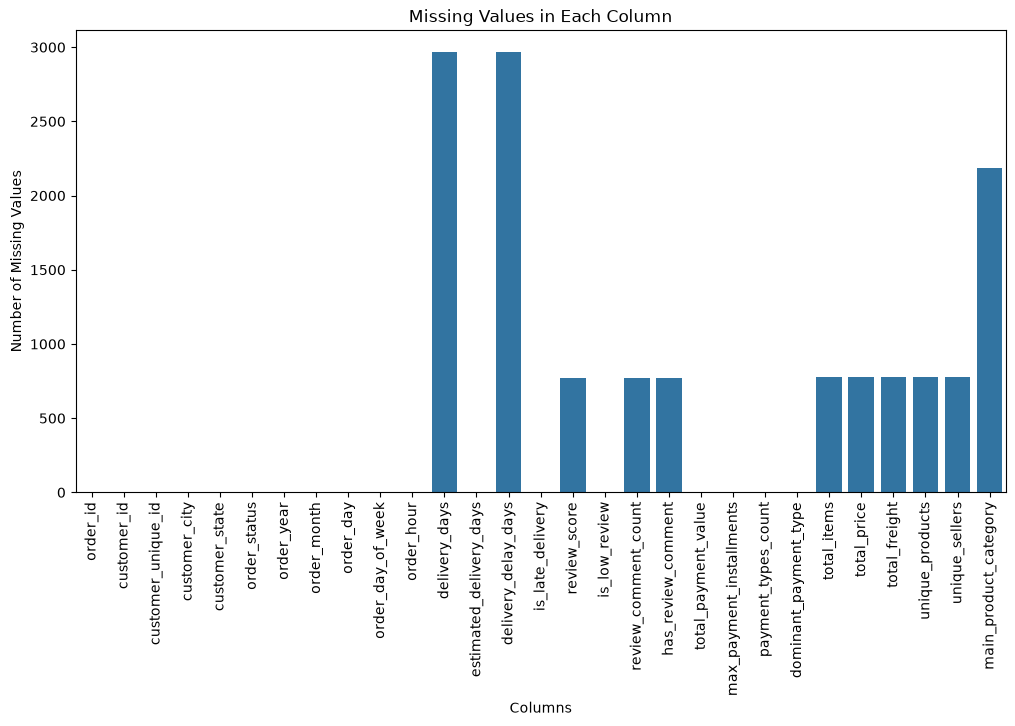

In [9]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=missing_summary.index,
    y=missing_summary["Missing Values"]
)

plt.xticks(rotation=90)
plt.title("Missing Values in Each Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.show()

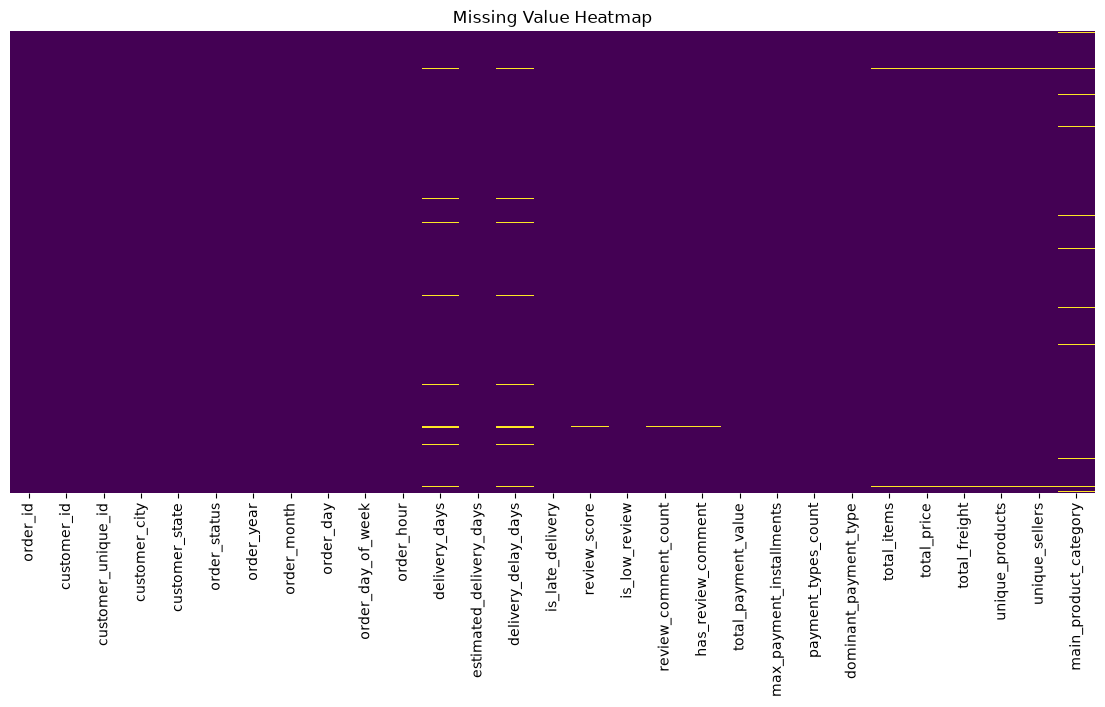

In [10]:
plt.figure(figsize=(14,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")
plt.show()

In [11]:
def keep_existing_columns(df, columns):
    return [col for col in columns if col in df.columns]

In [12]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical Columns:", len(numeric_columns))
print(numeric_columns)

print("\nCategorical Columns:", len(categorical_columns))
print(categorical_columns)

Numerical Columns: 21
['order_year', 'order_month', 'order_day', 'order_day_of_week', 'order_hour', 'delivery_days', 'estimated_delivery_days', 'delivery_delay_days', 'is_late_delivery', 'review_score', 'is_low_review', 'review_comment_count', 'has_review_comment', 'total_payment_value', 'max_payment_installments', 'payment_types_count', 'total_items', 'total_price', 'total_freight', 'unique_products', 'unique_sellers']

Categorical Columns: 8
['order_id', 'customer_id', 'customer_unique_id', 'customer_city', 'customer_state', 'order_status', 'dominant_payment_type', 'main_product_category']


C:\Users\avnij\AppData\Local\Temp\ipykernel_28392\1401316800.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns.tolist()


In [13]:
if "delivery_days" in df.columns:
    df["delivery_speed_category"] = pd.cut(
        df["delivery_days"],
        bins=[-np.inf, 3, 7, 14, np.inf],
        labels=["Very Fast", "Fast", "Normal", "Slow"]
    )

df["delivery_speed_category"].value_counts(dropna=False)

delivery_speed_category
Normal       36398
Slow         26380
Fast         25096
Very Fast     8602
NaN           2965
Name: count, dtype: int64

In [14]:
if "total_payment_value" in df.columns:
    df["payment_value_band"] = pd.qcut(
        df["total_payment_value"],
        q=4,
        labels=["Low", "Medium", "High", "Premium"],
        duplicates="drop"
    )

df["payment_value_band"].value_counts(dropna=False)

payment_value_band
Low        24912
Premium    24859
High       24855
Medium     24814
NaN            1
Name: count, dtype: int64

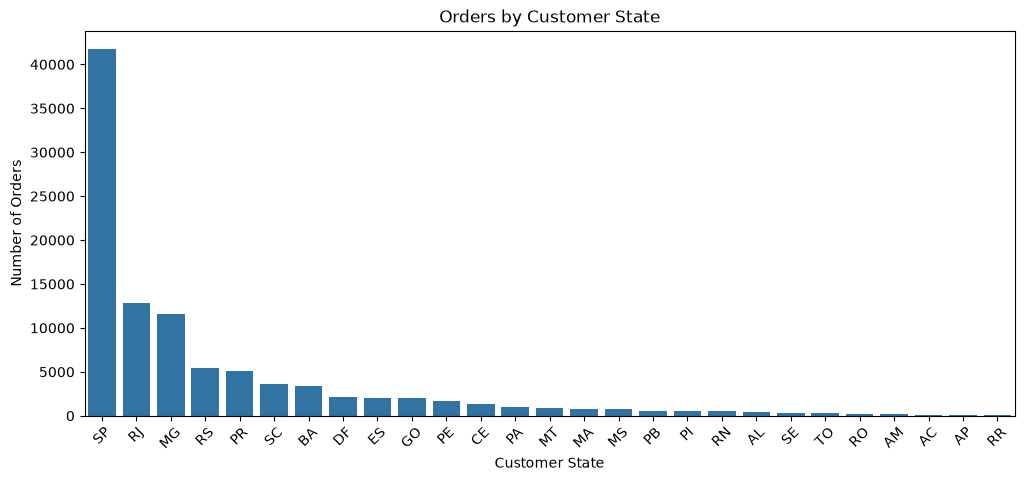

In [15]:
if "customer_state" in df.columns:
    plt.figure(figsize=(12,5))

    sns.countplot(
        data=df,
        x="customer_state",
        order=df["customer_state"].value_counts().index
    )

    plt.title("Orders by Customer State")
    plt.xlabel("Customer State")
    plt.ylabel("Number of Orders")
    plt.xticks(rotation=45)
    plt.show()

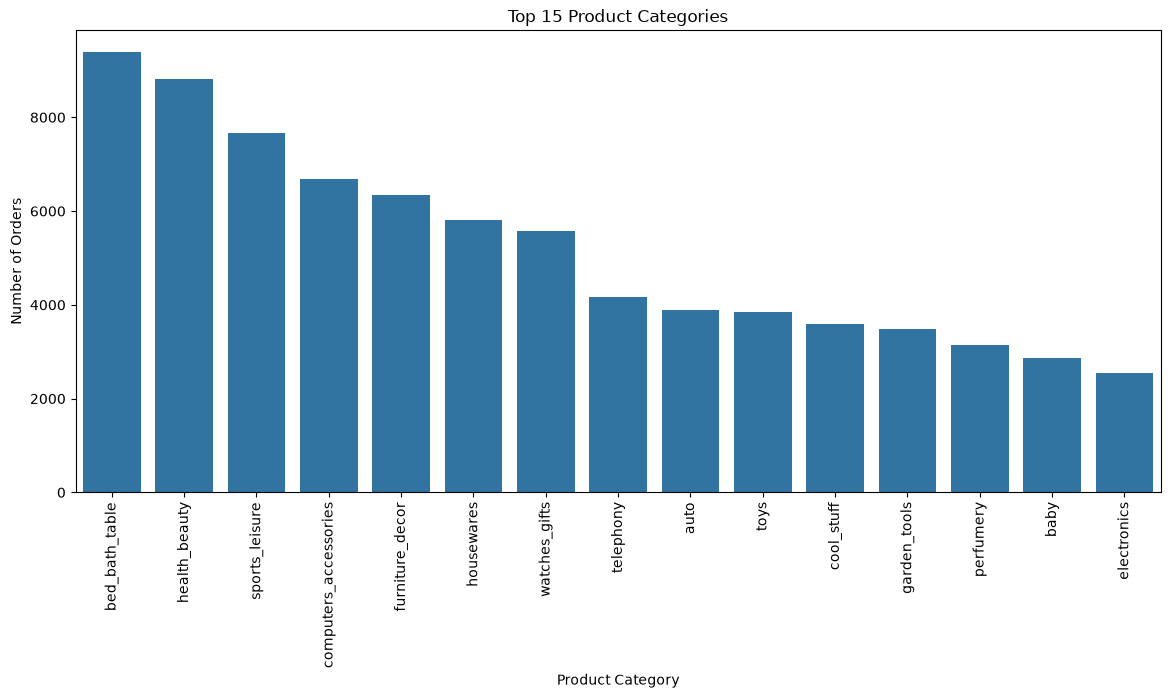

In [16]:
if "main_product_category" in df.columns:

    top_categories = (
        df["main_product_category"]
        .value_counts()
        .head(15)
        .index
    )

    plt.figure(figsize=(14,6))

    sns.countplot(
        data=df[df["main_product_category"].isin(top_categories)],
        x="main_product_category",
        order=top_categories
    )

    plt.xticks(rotation=90)
    plt.title("Top 15 Product Categories")
    plt.xlabel("Product Category")
    plt.ylabel("Number of Orders")
    plt.show()

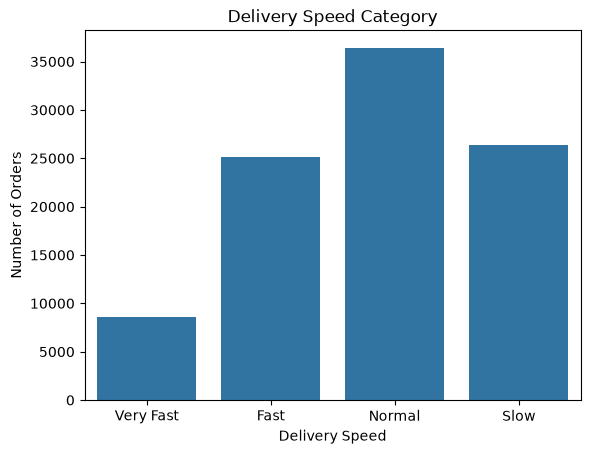

In [17]:
if "delivery_speed_category" in df.columns:

    sns.countplot(
        data=df,
        x="delivery_speed_category"
    )

    plt.title("Delivery Speed Category")
    plt.xlabel("Delivery Speed")
    plt.ylabel("Number of Orders")
    plt.show()

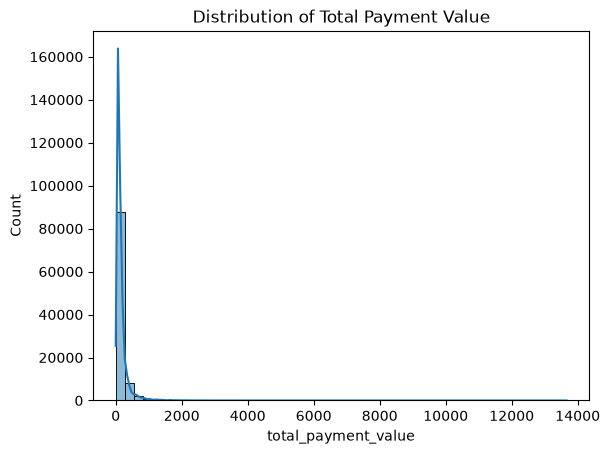

In [18]:
if "total_payment_value" in df.columns:

    sns.histplot(
        data=df,
        x="total_payment_value",
        bins=50,
        kde=True
    )

    plt.title("Distribution of Total Payment Value")
    plt.show()

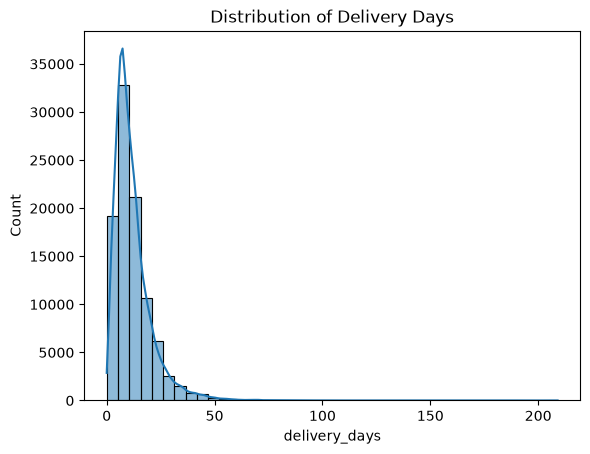

In [19]:
if "delivery_days" in df.columns:

    sns.histplot(
        data=df,
        x="delivery_days",
        bins=40,
        kde=True
    )

    plt.title("Distribution of Delivery Days")
    plt.show()

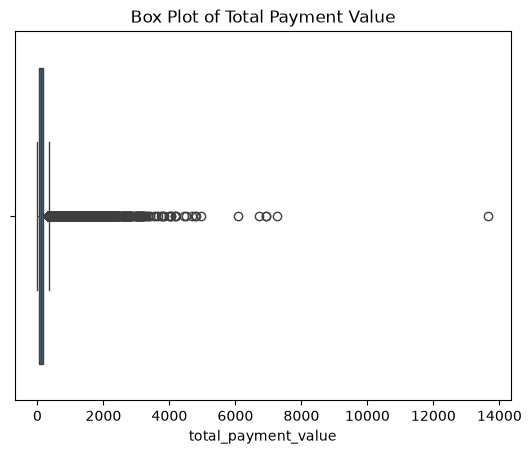

In [20]:
if "total_payment_value" in df.columns:

    sns.boxplot(
        x=df["total_payment_value"]
    )

    plt.title("Box Plot of Total Payment Value")
    plt.show()

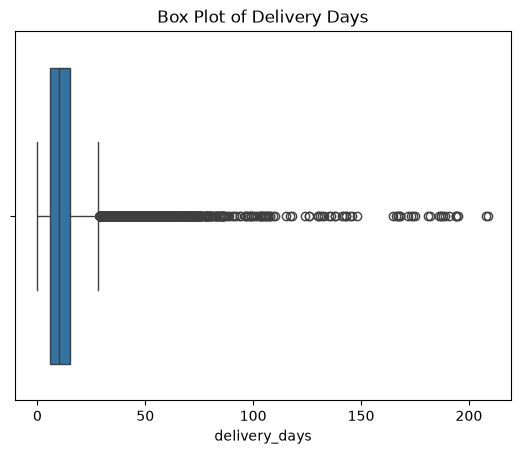

In [21]:
if "delivery_days" in df.columns:

    sns.boxplot(
        x=df["delivery_days"]
    )

    plt.title("Box Plot of Delivery Days")
    plt.show()

In [22]:
def iqr_outlier_summary(dataframe, column):

    q1 = dataframe[column].quantile(0.25)
    q3 = dataframe[column].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = dataframe[
        (dataframe[column] < lower) |
        (dataframe[column] > upper)
    ]

    summary = {
        "column": column,
        "outlier_count": len(outliers),
        "outlier_percent": (len(outliers) / len(dataframe)) * 100
    }

    return summary

In [23]:
if "total_payment_value" in df.columns:
    print(iqr_outlier_summary(df, "total_payment_value"))

if "delivery_days" in df.columns:
    print(iqr_outlier_summary(df, "delivery_days"))

{'column': 'total_payment_value', 'outlier_count': 7866, 'outlier_percent': 7.910218119286813}
{'column': 'delivery_days', 'outlier_count': 5025, 'outlier_percent': 5.053247654388029}


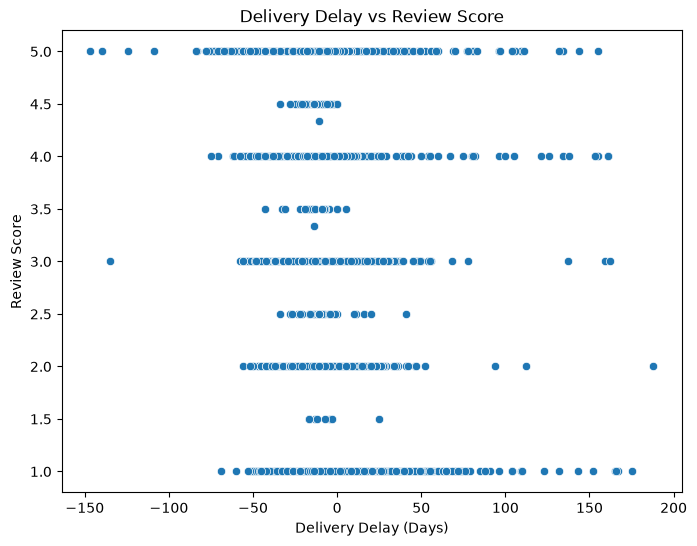

In [24]:
if {"delivery_delay_days", "review_score"}.issubset(df.columns):

    plt.figure(figsize=(8,6))

    sns.scatterplot(
        data=df,
        x="delivery_delay_days",
        y="review_score"
    )

    plt.title("Delivery Delay vs Review Score")
    plt.xlabel("Delivery Delay (Days)")
    plt.ylabel("Review Score")
    plt.show()

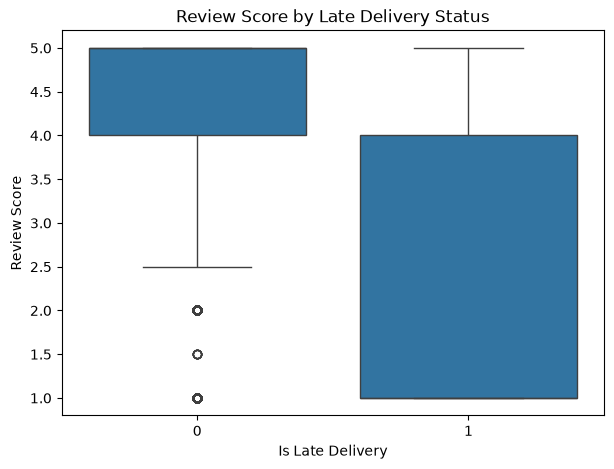

In [25]:
if {"is_late_delivery", "review_score"}.issubset(df.columns):

    plt.figure(figsize=(7,5))

    sns.boxplot(
        data=df,
        x="is_late_delivery",
        y="review_score"
    )

    plt.title("Review Score by Late Delivery Status")
    plt.xlabel("Is Late Delivery")
    plt.ylabel("Review Score")
    plt.show()

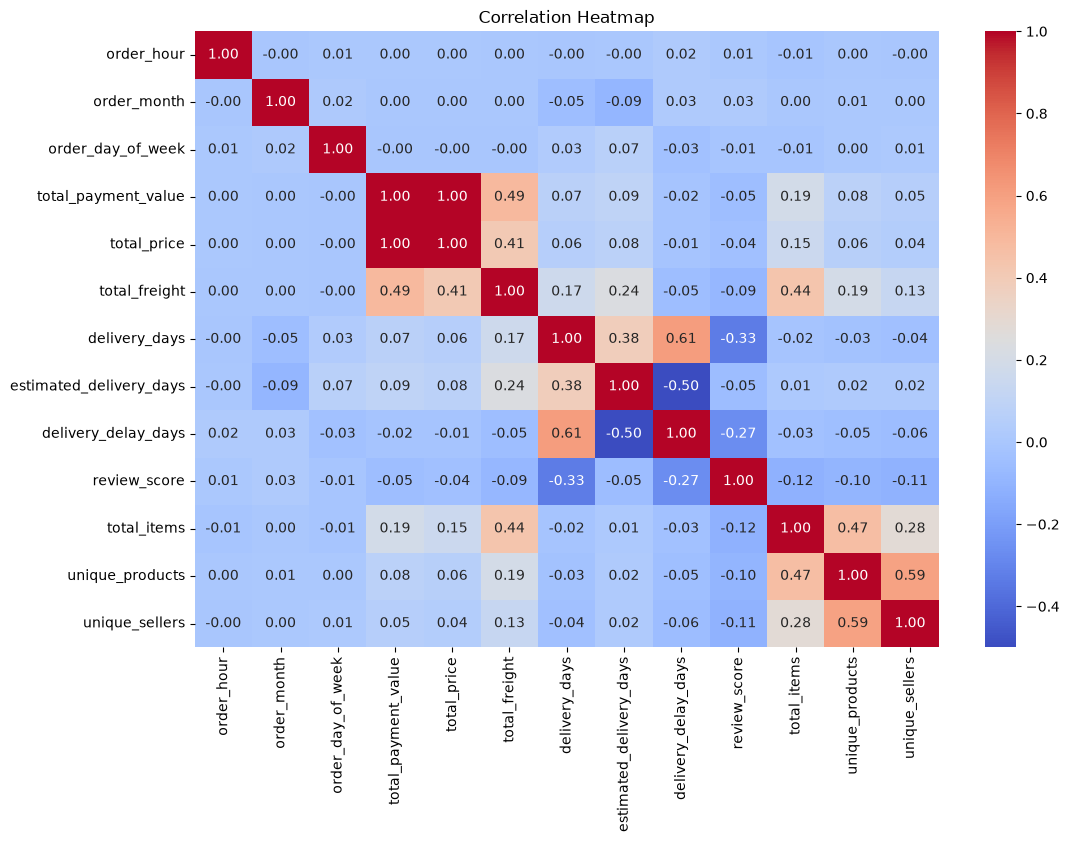

In [26]:
numeric_columns = [
    "order_hour",
    "order_month",
    "order_day_of_week",
    "total_payment_value",
    "total_price",
    "total_freight",
    "delivery_days",
    "estimated_delivery_days",
    "delivery_delay_days",
    "review_score",
    "total_items",
    "unique_products",
    "unique_sellers"
]

numeric_columns = keep_existing_columns(df, numeric_columns)

plt.figure(figsize=(12,8))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [27]:
clean_df = df.copy()

In [28]:
categorical_missing_cols = clean_df.select_dtypes(include="object").columns

for col in categorical_missing_cols:
    clean_df[col] = clean_df[col].fillna("Unknown")

numerical_missing_cols = [
    "total_payment_value",
    "total_price",
    "total_freight",
    "delivery_days",
    "estimated_delivery_days",
    "delivery_delay_days",
    "review_score",
    "total_items",
    "unique_products",
    "unique_sellers"
]

numerical_missing_cols = keep_existing_columns(
    clean_df,
    numerical_missing_cols
)

for col in numerical_missing_cols:
    clean_df[col] = clean_df[col].fillna(
        clean_df[col].median()
    )

C:\Users\avnij\AppData\Local\Temp\ipykernel_28392\3563071216.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_missing_cols = clean_df.select_dtypes(include="object").columns


In [29]:
clean_df.isnull().sum()

order_id                       0
customer_id                    0
customer_unique_id             0
customer_city                  0
customer_state                 0
order_status                   0
order_year                     0
order_month                    0
order_day                      0
order_day_of_week              0
order_hour                     0
delivery_days                  0
estimated_delivery_days        0
delivery_delay_days            0
is_late_delivery               0
review_score                   0
is_low_review                  0
review_comment_count         768
has_review_comment           768
total_payment_value            0
max_payment_installments       1
payment_types_count            1
dominant_payment_type          0
total_items                    0
total_price                    0
total_freight                  0
unique_products                0
unique_sellers                 0
main_product_category          0
delivery_speed_category     2965
payment_va

In [30]:
if "total_payment_value" in clean_df.columns:
    clean_df["log_total_payment_value"] = np.log1p(
        clean_df["total_payment_value"]
    )

if "total_freight" in clean_df.columns:
    clean_df["log_total_freight"] = np.log1p(
        clean_df["total_freight"]
    )

if "total_price" in clean_df.columns:
    clean_df["log_total_price"] = np.log1p(
        clean_df["total_price"]
    )

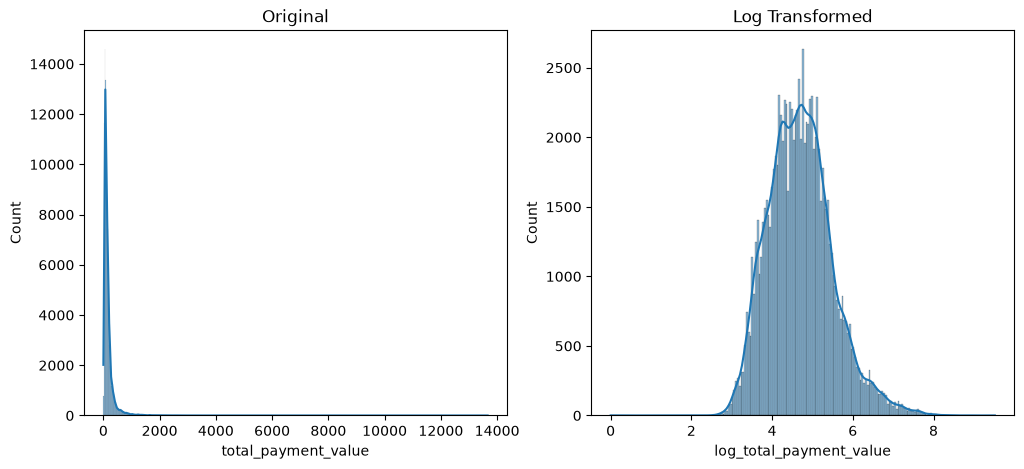

In [31]:
if {
    "total_payment_value",
    "log_total_payment_value"
}.issubset(clean_df.columns):

    fig, axes = plt.subplots(1,2, figsize=(12,5))

    sns.histplot(
        clean_df["total_payment_value"],
        kde=True,
        ax=axes[0]
    )

    axes[0].set_title("Original")

    sns.histplot(
        clean_df["log_total_payment_value"],
        kde=True,
        ax=axes[1]
    )

    axes[1].set_title("Log Transformed")

    plt.show()

In [32]:
from sklearn.preprocessing import StandardScaler

scale_columns = [
    "total_payment_value",
    "total_price",
    "total_freight"
]

scale_columns = keep_existing_columns(
    clean_df,
    scale_columns
)

scaler = StandardScaler()

clean_df[scale_columns] = scaler.fit_transform(
    clean_df[scale_columns]
)

clean_df[scale_columns].head()

,total_payment_value,total_price,total_freight
0,-0.550936,-0.511593,-0.651748
1,-0.087992,-0.088902,-0.000904
2,0.081687,0.107411,-0.165006
3,-0.400045,-0.440073,0.204918
4,-0.596397,-0.559671,-0.651748


In [33]:
leakage_columns = [
    "delivery_delay_days",
    "delivery_speed_category"
]

print("Potential Leakage Columns:")
print(leakage_columns)

Potential Leakage Columns:
['delivery_delay_days', 'delivery_speed_category']


In [34]:
clean_df.to_csv(
    PROCESSED_DIR / "olist_orders_abt_cleaned.csv",
    index=False
)

print("Cleaned ABT saved successfully.")
print(clean_df.shape)

Cleaned ABT saved successfully.
(99441, 34)


In [35]:
(PROCESSED_DIR / "olist_orders_abt_cleaned.csv").exists()

True